In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
import sys
import json
import numpy as np
import pandas as pd
from statistics import  mean, multimode

In [3]:
main_dir = os.path.dirname(os.getcwd())
BASE_DIR   = os.path.join(main_dir, "facet_data")
IMG_DIRS   = [os.path.join(BASE_DIR, d) for d in ("imgs_1", "imgs_2", "imgs_3")]
ANN_FILE   = os.path.join(BASE_DIR, "annotations", "annotations.csv")
OUTPUT_CSV = os.path.join(BASE_DIR, "facet_dataset.csv")

In [4]:
df_ann = pd.read_csv(ANN_FILE)

df_ann_new = df_ann.copy()

# 2) Detectar columnas de frecuencia de skin tone (1–10)
skin_cols = [c for c in df_ann_new.columns if c.startswith("skin_tone_") and c != "skin_tone_na"]

mask_any = df_ann_new[skin_cols].sum(axis=1) > 0
df_ann_new = df_ann_new[mask_any].reset_index(drop=True)


df_ann_new['bbox_dict'] = df_ann_new['bounding_box'].apply(json.loads)
df_ann_new[['x','y','width','height']] = df_ann_new['bbox_dict'].apply(
    lambda b: pd.Series([b['x'], b['y'], b['width'], b['height']]))

# 3) Función para elegir el tono más frecuente (tie‐break: mayor valor)
def pick_by_freq(row):
    freqs     = row[skin_cols]
    max_count = freqs.max()                       # p. ej. 2
    # extraigo todos los tonos que alcanzan ese count
    candidates = [int(col.split('_')[-1])
                    for col in skin_cols
                    if row[col] == max_count]
    return max(candidates) if candidates else None

df_ann_new['skin_tone_final'] = df_ann_new.apply(pick_by_freq, axis=1)

path_dict = {}
for img_dir in IMG_DIRS:
    for fname in os.listdir(img_dir):
        if fname.lower().endswith('.jpg'):
            path_dict[fname] = os.path.join(img_dir, fname)
df_ann_new.loc[:, 'image_path'] = df_ann_new['filename'].map(path_dict)
# 4) Construir DataFrame con persona + coords + tono
df_ann_out = df_ann_new[[
    'image_path',
    'filename',
    'person_id',
    'x','y','width','height',
    'skin_tone_final'
]]

In [5]:
df_ann_out

,image_path,filename,person_id,x,y,width,height,skin_tone_final
0,/home/diegopaez/MoQ-NAS/facet_data/imgs_1/sa_3...,sa_3532701.jpg,350155620665729,120.66,629.34,934.54,591.48,2
1,/home/diegopaez/MoQ-NAS/facet_data/imgs_2/sa_7...,sa_7347673.jpg,351314803874856,1674.89,668.60,404.47,831.30,3
2,/home/diegopaez/MoQ-NAS/facet_data/imgs_3/sa_9...,sa_9002416.jpg,351640253843285,1274.01,312.17,1101.80,1187.68,7
3,/home/diegopaez/MoQ-NAS/facet_data/imgs_2/sa_1...,sa_10328086.jpg,352432200438806,47.58,648.04,503.02,589.12,5
4,/home/diegopaez/MoQ-NAS/facet_data/imgs_3/sa_8...,sa_8736204.jpg,352621790416110,1554.28,283.22,79.93,173.68,9
...,...,...,...,...,...,...,...,...
44928,/home/diegopaez/MoQ-NAS/facet_data/imgs_1/sa_8...,sa_8151725.jpg,9250745724951614,137.23,118.09,775.53,1372.34,3
44929,/home/diegopaez/MoQ-NAS/facet_data/imgs_1/sa_9...,sa_9291116.jpg,9263831723642501,518.84,601.03,626.71,1263.70,3
44930,/home/diegopaez/MoQ-NAS/facet_data/imgs_2/sa_1...,sa_1181162.jpg,9265131896837616,1208.27,278.66,1134.25,1177.79,7
44931,/home/diegopaez/MoQ-NAS/facet_data/imgs_3/sa_1...,sa_10224094.jpg,9317227781624426,318.49,452.05,784.25,1037.67,3


In [26]:
df_ann.columns

Index(['Unnamed: 0', 'person_id', 'filename', 'class1', 'class2',
       'bounding_box', 'gender_presentation_masc', 'gender_presentation_fem',
       'gender_presentation_non_binary', 'gender_presentation_na',
       'skin_tone_1', 'skin_tone_2', 'skin_tone_3', 'skin_tone_4',
       'skin_tone_5', 'skin_tone_6', 'skin_tone_7', 'skin_tone_8',
       'skin_tone_9', 'skin_tone_10', 'skin_tone_na', 'age_presentation_young',
       'age_presentation_older', 'age_presentation_middle',
       'age_presentation_na', 'hair_color_brown', 'hair_color_blonde',
       'hair_color_grey', 'hair_color_na', 'hair_color_black',
       'hair_color_colored', 'hair_color_red', 'hairtype_coily',
       'hairtype_dreadlocks', 'hairtype_bald', 'hairtype_straight',
       'hairtype_curly', 'hairtype_wavy', 'hairtype_na', 'has_facial_hair',
       'has_tattoo', 'has_cap', 'has_mask', 'has_headscarf', 'has_eyeware',
       'visible_torso', 'visible_face', 'visible_minimal',
       'lighting_underexposed', 'ligh

In [22]:
df_ann['skin_tone_2'].values[1]

np.int64(0)

In [ ]:
# print the values of df_ann for the skin_cols 
count = 0
for file_name in df_ann_out['filename'].unique():
    print(f"File: {file_name}")
    sample_df = df_ann[df_ann['filename'] == file_name]
    for col in skin_cols:
        print(f"{col}: {sample_df[col].values[0]}")
    print(f"Skin Tone Final: {df_ann_out[df_ann_out['filename'] == file_name]['skin_tone_final'].values[0]}")
    print('--'* 20)
    count += 1
    if count > 10:
        break

File: sa_3532701.jpg
skin_tone_1: 2
skin_tone_2: 3
skin_tone_3: 0
skin_tone_4: 0
skin_tone_5: 0
skin_tone_6: 0
skin_tone_7: 0
skin_tone_8: 0
skin_tone_9: 0
skin_tone_10: 0
Skin Tone Final: 2
----------------------------------------
File: sa_7347673.jpg
skin_tone_1: 0
skin_tone_2: 0
skin_tone_3: 2
skin_tone_4: 0
skin_tone_5: 0
skin_tone_6: 0
skin_tone_7: 0
skin_tone_8: 0
skin_tone_9: 0
skin_tone_10: 0
Skin Tone Final: 3
----------------------------------------
File: sa_9002416.jpg
skin_tone_1: 0
skin_tone_2: 0
skin_tone_3: 0
skin_tone_4: 0
skin_tone_5: 1
skin_tone_6: 1
skin_tone_7: 2
skin_tone_8: 1
skin_tone_9: 0
skin_tone_10: 0
Skin Tone Final: 7
----------------------------------------
File: sa_10328086.jpg
skin_tone_1: 0
skin_tone_2: 0
skin_tone_3: 1
skin_tone_4: 2
skin_tone_5: 3
skin_tone_6: 1
skin_tone_7: 0
skin_tone_8: 0
skin_tone_9: 0
skin_tone_10: 0
Skin Tone Final: 5
----------------------------------------
File: sa_8736204.jpg
skin_tone_1: 0
skin_tone_2: 0
skin_tone_3: 0
skin_

In [55]:
out_path = os.path.join(BASE_DIR, 'facet_dataset_coords.csv')
df_ann_out.to_csv(out_path, index=False)

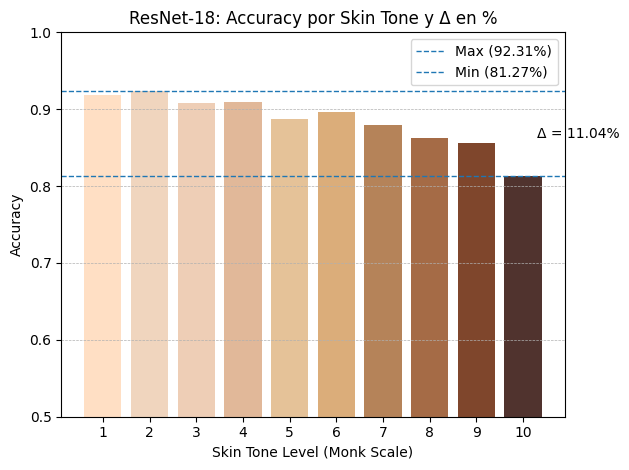

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'ResNet-18: Accuracy por Skin Tone y Δ en %'}, xlabel='Skin Tone Level (Monk Scale)', ylabel='Accuracy'>)

In [10]:
import matplotlib.pyplot as plt

def plot_skin_tone_accuracy(accuracies, model_name):
    """
    Dibuja un gráfico de barras de accuracy por nivel de skin tone (Monk Scale),
    con líneas punteadas para Max y Min, y anotación de Δ en porcentaje.
    
    Parámetros:
    - accuracies: lista de floats con accuracy para cada tono (1–10).
    - model_name: string con el nombre del modelo (usado en el título).
    """
    tones = list(range(1, len(accuracies) + 1))
    
    # Colores de la escala Monk Skin Tone
    monk_colors = [
        "#FFDFC4", "#F0D5BE", "#EECEB6", "#E1B899", "#E5C298",
        "#DBAD7A", "#B58359", "#A56B46", "#7F462C", "#50332E"
    ][:len(tones)]
    
    # Cálculo de max, min y delta
    max_acc = max(accuracies)
    min_acc = min(accuracies)
    delta = max_acc - min_acc
    
    # Creación de la figura
    fig, ax = plt.subplots()
    
    # Gráfico de barras
    ax.bar(tones, accuracies, color=monk_colors)
    
    # Líneas de Max y Min
    ax.axhline(max_acc, linestyle='--', linewidth=1, label=f'Max ({max_acc*100:.2f}%)')
    ax.axhline(min_acc, linestyle='--', linewidth=1, label=f'Min ({min_acc*100:.2f}%)')
    
    # Anotación de Δ en la derecha
    x_text = tones[-1] + 0.3
    y_text = (max_acc + min_acc) / 2
    ax.text(x_text, y_text, f'Δ = {delta*100:.2f}%', va='center')
    
    # Configuraciones
    ax.set_xticks(tones)
    ax.set_xlabel("Skin Tone Level (Monk Scale)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{model_name}: Accuracy por Skin Tone y Δ en %")
    ax.set_ylim(0.5, 1.0)
    ax.legend()
    ax.grid(axis="y", linestyle="--", linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    return fig, ax

# Ejemplo de uso con ResNet-18
accuracies_resnet = [0.9180, 0.9231, 0.9085, 0.9088, 0.8879, 0.8965, 0.8800, 0.8621, 0.8557, 0.8127]
plot_skin_tone_accuracy(accuracies_resnet, "ResNet-18")


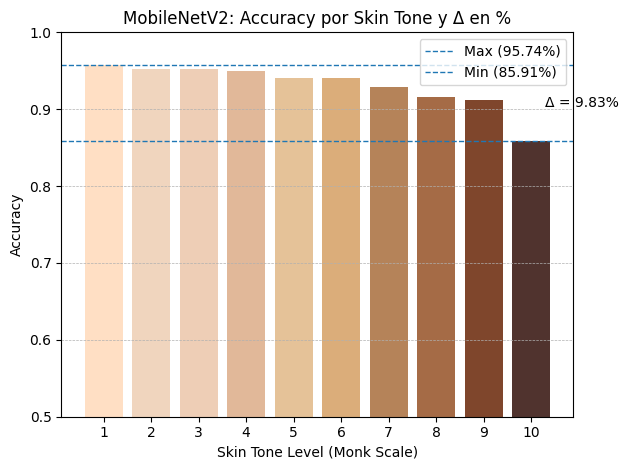

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'MobileNetV2: Accuracy por Skin Tone y Δ en %'}, xlabel='Skin Tone Level (Monk Scale)', ylabel='Accuracy'>)

In [12]:
accuracies_mobilenet = [0.9574,0.9526,0.9517,0.9499,0.9406,0.9403,0.9290,0.9155,0.9124,0.8591]
plot_skin_tone_accuracy(accuracies_mobilenet, "MobileNetV2")